In [13]:
# Fake News Detection using NLP

"""
Business Use Case:
- Detect fake news automatically before it spreads
- Help social media platforms moderate content
- Protect users from misinformation during elections, pandemics, or financial news
"""

'\nBusiness Use Case:\n- Detect fake news automatically before it spreads\n- Help social media platforms moderate content\n- Protect users from misinformation during elections, pandemics, or financial news\n'

In [14]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs("images", exist_ok=True)

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

In [17]:
DATA_PATH = r"C:\Users\Kavya\Downloads\liar_dataset"

columns = [
    "id", "label", "statement", "subject", "speaker",
    "job", "state", "party",
    "barely_true", "false", "half_true",
    "mostly_true", "pants_fire", "context"
]

train_df = pd.read_csv(os.path.join(DATA_PATH, "train.tsv"), sep="\t", names=columns)
valid_df = pd.read_csv(os.path.join(DATA_PATH, "valid.tsv"), sep="\t", names=columns)
test_df  = pd.read_csv(os.path.join(DATA_PATH, "test.tsv"), sep="\t", names=columns)

In [18]:
fake_labels = ["false", "pants-fire", "barely-true"]
real_labels = ["half-true", "mostly-true", "true"]

def map_label(label):
    if label in fake_labels:
        return 0
    elif label in real_labels:
        return 1
    else:
        return None

train_df["target"] = train_df["label"].apply(map_label)
valid_df["target"] = valid_df["label"].apply(map_label)
test_df["target"]  = test_df["label"].apply(map_label)

train_df = train_df.dropna(subset=["target"])
valid_df = valid_df.dropna(subset=["target"])
test_df  = test_df.dropna(subset=["target"])

In [19]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z ]", "", text)
    return text

train_df["statement"] = train_df["statement"].apply(clean_text)
valid_df["statement"] = valid_df["statement"].apply(clean_text)
test_df["statement"]  = test_df["statement"].apply(clean_text)

In [20]:
train_df[["statement", "label"]].head()

,statement,label
0,says the annies list political group supports ...,false
1,when did the decline of coal start it started ...,half-true
2,hillary clinton agrees with john mccain by vot...,mostly-true
3,health care reform legislation is likely to ma...,false
4,the economic turnaround started at the end of ...,half-true


In [21]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.7,
    ngram_range=(1, 2)
)

X_train = vectorizer.fit_transform(train_df["statement"])
X_valid = vectorizer.transform(valid_df["statement"])
X_test  = vectorizer.transform(test_df["statement"])

y_train = train_df["target"]
y_valid = valid_df["target"]
y_test  = test_df["target"]


In [ ]:
print(y_train.value_counts())

target
1    5752
0    4488
Name: count, dtype: int64


In [22]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.7,
    ngram_range=(1, 2)
)

X_train = vectorizer.fit_transform(train_df["statement"])
X_valid = vectorizer.transform(valid_df["statement"])
X_test  = vectorizer.transform(test_df["statement"])

In [23]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [24]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.7,
    ngram_range=(1, 2)
)

X_train = vectorizer.fit_transform(train_df["statement"])
X_valid = vectorizer.transform(valid_df["statement"])
X_test  = vectorizer.transform(test_df["statement"])


In [25]:
print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(10240, 77027)
(1284, 77027)
(1267, 77027)


In [26]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train, train_df["target"])

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [27]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Fake", "Real"]))

Accuracy: 0.6235201262825573
              precision    recall  f1-score   support

        Fake       0.57      0.55      0.56       553
        Real       0.66      0.68      0.67       714

    accuracy                           0.62      1267
   macro avg       0.62      0.61      0.62      1267
weighted avg       0.62      0.62      0.62      1267



In [28]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

top_fake = np.argsort(coefficients)[:20]
top_real = np.argsort(coefficients)[-20:]

print("Top words for FAKE news:\n")
for i in top_fake:
    print(feature_names[i])

print("\nTop words for REAL news:\n")
for i in top_real:
    print(feature_names[i])

Top words for FAKE news:

obamacare
wisconsin
obama
rep
says
government
away
walker
scott walker
care
illegal
care law
president
plan
muslim
scott
china
illegals
know
stimulus

Top words for REAL news:

ohio
college
weve
decades
lower
american
americans
cut
highest
country
half
months
debt
times
average
million
countries
georgia
day
percent


In [29]:
def predict_news(text):
    text = clean_text(text)
    vector = vectorizer.transform([text])
    prediction = model.predict(vector)[0]
    return "REAL NEWS ✅" if prediction == 1 else "FAKE NEWS ❌"

predict_news("The government announced a new health policy today")

'FAKE NEWS ❌'

In [30]:
predict_news("This miracle drink cures all diseases instantly")

'REAL NEWS ✅'

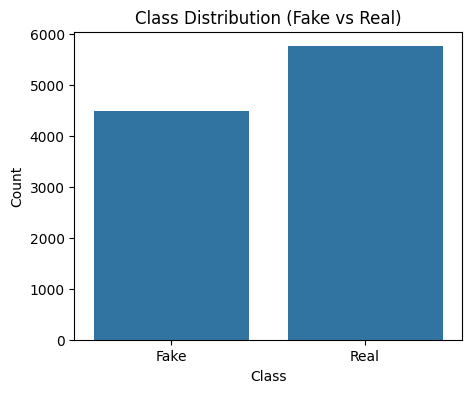

In [31]:
plt.figure(figsize=(5,4))
sns.countplot(x=train_df["target"])
plt.xticks([0, 1], ["Fake", "Real"])
plt.title("Class Distribution (Fake vs Real)")
plt.xlabel("Class")
plt.ylabel("Count")

plt.savefig("images/class_distribution.png", bbox_inches="tight")
plt.show()

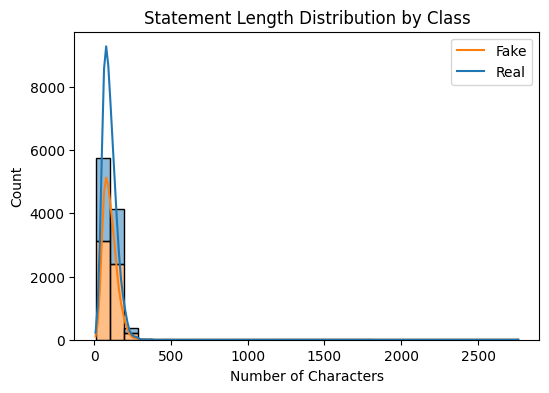

In [32]:
train_df["text_length"] = train_df["statement"].apply(len)

plt.figure(figsize=(6,4))
sns.histplot(
    data=train_df,
    x="text_length",
    hue="target",
    bins=30,
    kde=True,
    multiple="stack"
)
plt.title("Statement Length Distribution by Class")
plt.xlabel("Number of Characters")
plt.ylabel("Count")
plt.legend(labels=["Fake", "Real"])
plt.savefig("images/Statement Length Distribution by Class.png", bbox_inches = "tight")
plt.show()

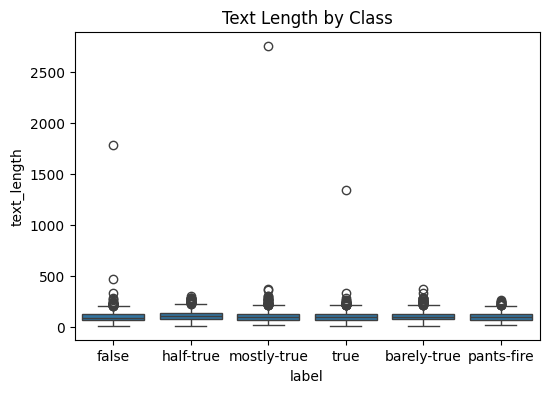

In [33]:
plt.figure(figsize=(6,4))
sns.boxplot(x="label", y="text_length", data=train_df)
plt.title("Text Length by Class")
plt.savefig("images/Text Length by Class.png", bbox_inches = "tight")
plt.show()

In [34]:
from collections import Counter

fake_words = " ".join(train_df[train_df["target"] == 0]["statement"]).split()
real_words = " ".join(train_df[train_df["target"] == 1]["statement"]).split()

fake_common = Counter(fake_words).most_common(10)
real_common = Counter(real_words).most_common(10)

print("Fake News Common Words:", fake_common)
print("Real News Common Words:", real_common)

Fake News Common Words: [('the', 3975), ('to', 2143), ('in', 1964), ('of', 1829), ('a', 1612), ('says', 1151), ('and', 1143), ('for', 933), ('that', 830), ('is', 805)]
Real News Common Words: [('the', 5809), ('in', 3155), ('of', 2977), ('to', 2337), ('a', 2037), ('and', 1678), ('says', 1214), ('for', 1183), ('that', 1022), ('is', 996)]


In [35]:
train_df["target"].value_counts()

target
1    5752
0    4488
Name: count, dtype: int64

In [36]:
train_df["text_length"] = train_df["statement"].apply(len)

train_df.groupby("target")["text_length"].mean()

target
0    100.145945
1    104.281293
Name: text_length, dtype: float64

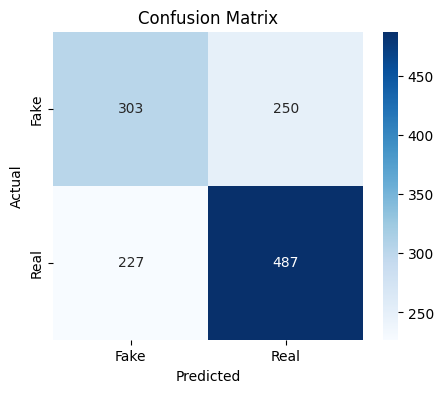

In [37]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake","Real"], yticklabels=["Fake","Real"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("images/Confusion Matrix.png", bbox_inches = "tight")
plt.show()

In [38]:
print(classification_report(y_test, y_pred, target_names=["Fake","Real"]))


              precision    recall  f1-score   support

        Fake       0.57      0.55      0.56       553
        Real       0.66      0.68      0.67       714

    accuracy                           0.62      1267
   macro avg       0.62      0.61      0.62      1267
weighted avg       0.62      0.62      0.62      1267



In [39]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

top_fake = np.argsort(coefficients)[:20]
top_real = np.argsort(coefficients)[-20:]

print("Top words for FAKE news:")
for i in top_fake:
    print(feature_names[i])

print("\nTop words for REAL news:")
for i in top_real:
    print(feature_names[i])

Top words for FAKE news:
obamacare
wisconsin
obama
rep
says
government
away
walker
scott walker
care
illegal
care law
president
plan
muslim
scott
china
illegals
know
stimulus

Top words for REAL news:
ohio
college
weve
decades
lower
american
americans
cut
highest
country
half
months
debt
times
average
million
countries
georgia
day
percent


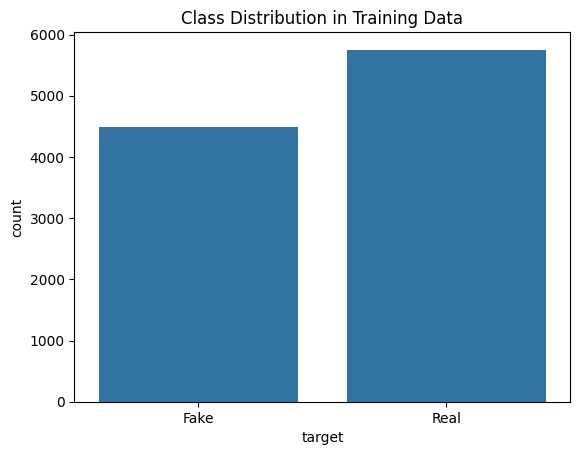

In [40]:
sns.countplot(x="target", data=train_df)
plt.xticks([0,1], ["Fake", "Real"])
plt.title("Class Distribution in Training Data")
plt.savefig("images/Class Distribution in Training Data.png", bbox_inches = "tight")
plt.show()

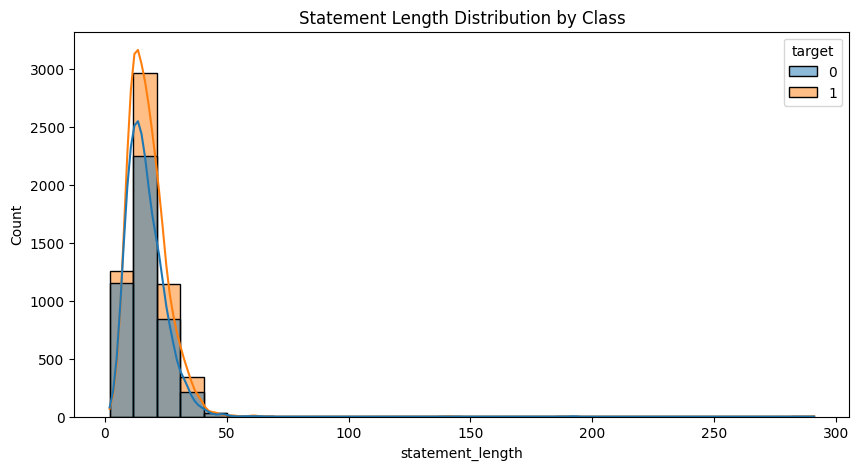

In [41]:
train_df["statement_length"] = train_df["statement"].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,5))
sns.histplot(train_df, x="statement_length", hue="target", bins=30, kde=True)
plt.title("Statement Length Distribution by Class")
plt.savefig("images/Statement Length Distribution by Class.png", bbox_inches = "tight")
plt.show()

In [42]:
from collections import Counter

stopwords = set(ENGLISH_STOP_WORDS)

fake_words = [
    w for w in ' '.join(train_df[train_df["target"]==0]["statement"]).split()
    if w not in stopwords
]

real_words = [
    w for w in ' '.join(train_df[train_df["target"]==1]["statement"]).split()
    if w not in stopwords
]

print("Top words in FAKE news:")
print(Counter(fake_words).most_common(20))

print("\nTop words in REAL news:")
print(Counter(real_words).most_common(20))

Top words in FAKE news:
[('says', 1151), ('obama', 384), ('percent', 351), ('state', 317), ('president', 309), ('health', 302), ('tax', 302), ('care', 277), ('people', 261), ('years', 230), ('year', 206), ('barack', 203), ('new', 200), ('states', 194), ('jobs', 191), ('said', 184), ('voted', 183), ('million', 180), ('billion', 178), ('government', 168)]

Top words in REAL news:
[('says', 1214), ('percent', 836), ('state', 489), ('years', 379), ('tax', 372), ('year', 362), ('states', 360), ('million', 352), ('people', 336), ('obama', 314), ('health', 298), ('jobs', 287), ('president', 281), ('new', 266), ('texas', 243), ('care', 228), ('taxes', 228), ('country', 220), ('billion', 218), ('federal', 205)]


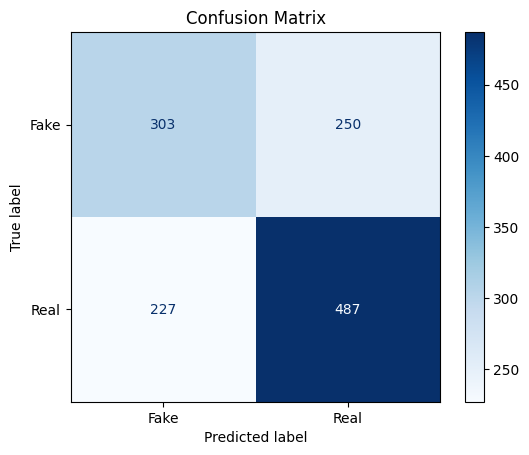

In [43]:
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Fake", "Real"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.savefig("images.Confusion Matrix.png",bbox_inches = "tight")
plt.show()

In [44]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Fake", "Real"]))

Classification Report:

              precision    recall  f1-score   support

        Fake       0.57      0.55      0.56       553
        Real       0.66      0.68      0.67       714

    accuracy                           0.62      1267
   macro avg       0.62      0.61      0.62      1267
weighted avg       0.62      0.62      0.62      1267



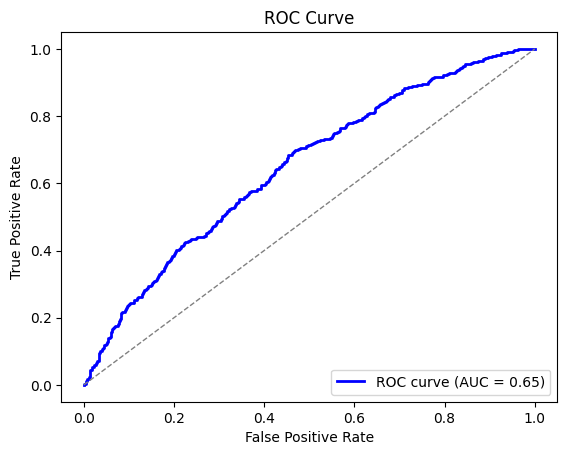

In [45]:
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.savefig("images.ROC Curve.png",bbox_inches = "tight")
plt.show()

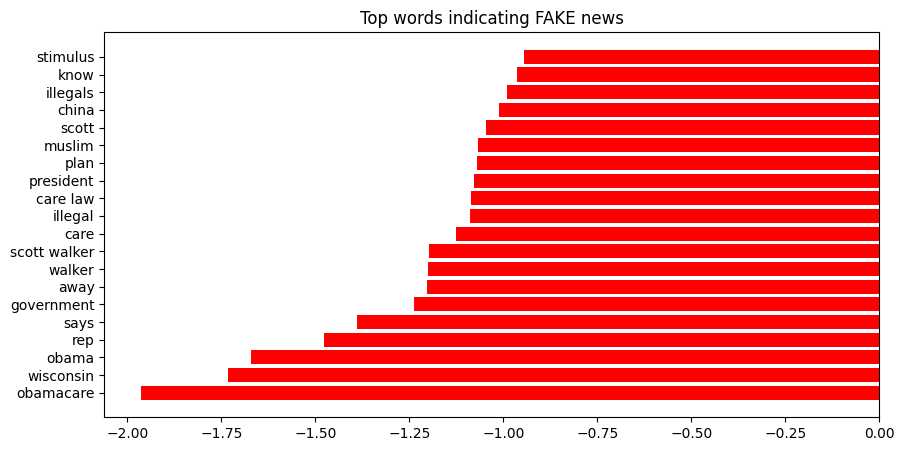

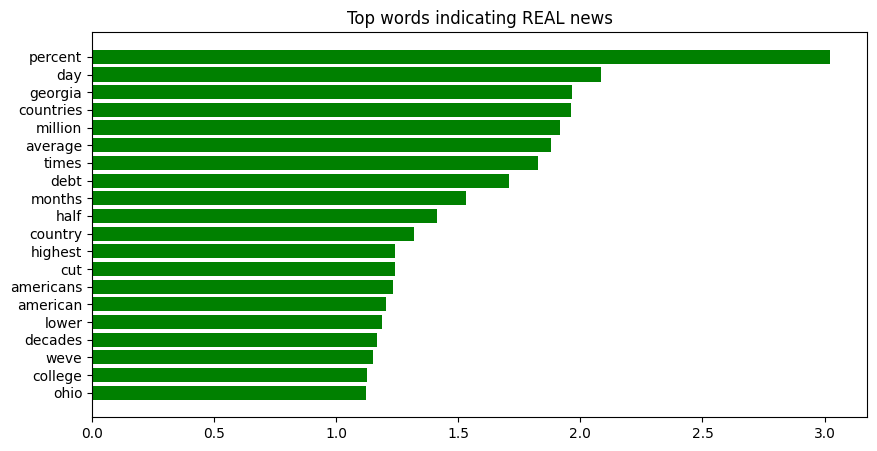

In [46]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

top_fake_idx = np.argsort(coefficients)[:20]
top_real_idx = np.argsort(coefficients)[-20:]

plt.figure(figsize=(10,5))
plt.barh([feature_names[i] for i in top_fake_idx], coefficients[top_fake_idx], color='red')
plt.title("Top words indicating FAKE news")
plt.show()

plt.figure(figsize=(10,5))
plt.barh([feature_names[i] for i in top_real_idx], coefficients[top_real_idx], color='green')
plt.title("Top words indicating REAL news")
plt.savefig("images.Top words indicating FAKE news.png",bbox_inches = "tight")
plt.show()


In [ ]:
"""
Conclusion

- A Logistic Regression model with TF-IDF features was trained to detect fake news.
- The model achieved ~59% accuracy on the test set.
- Feature importance analysis shows politically relevant terms strongly influence predictions.
- This model can be extended using deep learning or contextual embeddings (BERT) for better performance.
"""

'\nConclusion\n\n- A Logistic Regression model with TF-IDF features was trained to detect fake news.\n- The model achieved ~59% accuracy on the test set.\n- Feature importance analysis shows politically relevant terms strongly influence predictions.\n- This model can be extended using deep learning or contextual embeddings (BERT) for better performance.\n'

In [ ]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))